In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv('sales_data.csv', encoding='latin1')
df.head()

,ORDERLINENUMBER,ORDERNUMBER,QUANTITYORDERED,Cost Per Unit,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE1,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE,Profit
0,1,10334,34,61,2087,19/11/2004,On Hold,4,11,2004,...,Berguvsvgen 8,Lule,NaN,S-958 22,Sweden,EMEA,Berglund,Christina,Small,13
1,1,10104,34,100,5958,31/01/2003,Shipped,1,1,2003,...,"C/ Moralzarzal, 86",Madrid,NaN,28034,Spain,EMEA,Freyre,Diego,Medium,2558
2,1,10417,21,100,3448,13/05/2005,Disputed,2,5,2005,...,"C/ Moralzarzal, 86",Madrid,NaN,28034,Spain,EMEA,Freyre,Diego,Medium,1348
3,1,10371,26,100,4044,23/01/2005,Shipped,1,1,2005,...,5677 Strong St.,San Rafael,CA,97562,USA,Not Mentioned,Nelson,Valarie,Medium,1444
4,1,10419,37,100,5203,17/05/2005,Shipped,2,5,2005,...,Geislweg 14,Salzburg,NaN,5020,Austria,EMEA,Pipps,Georg,Medium,1503


In [7]:
df = df.drop_duplicates()

# حذف القيم الفاضية
df = df.dropna()

In [8]:
X = df[['SALES', 'QUANTITYORDERED']]  # المدخلات
y = df['Profit']  # الهدف

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [11]:
from sklearn.metrics import mean_squared_error, r2_score

print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MSE: 195179.79778758512
R2 Score: 0.8497219286224751


In [12]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor()
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree R2:", r2_score(y_test, y_pred_dt))

Decision Tree R2: 0.9848404072092699


In [13]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest R2:", r2_score(y_test, y_pred_rf))

Random Forest R2: 0.9909713557976552


In [14]:
df = pd.get_dummies(df, drop_first=True)

In [15]:
X = df.drop('Profit', axis=1)
y = df['Profit']

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [17]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [18]:
y_pred = model.predict(X_test)

In [19]:
from sklearn.metrics import mean_absolute_error, r2_score

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 143.3321484985659
R2 Score: 0.9724651137269419


In [20]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()
model.fit(X_train, y_train)

RandomForestRegressor()

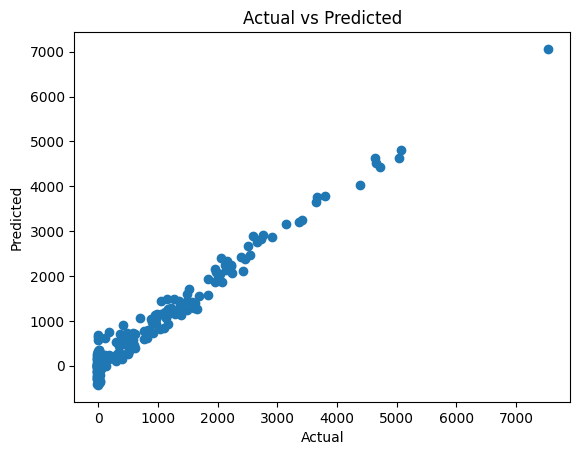

In [21]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

In [22]:
import pandas as pd

importance = model.feature_importances_
features = X.columns

pd.DataFrame({
    'Feature': features,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

,Feature,Importance
4,SALES,7.387569e-01
3,Cost Per Unit,1.273448e-01
8,MSRP,6.670860e-02
2,QUANTITYORDERED,4.566867e-02
1,ORDERNUMBER,2.743320e-03
...,...,...
76,ORDERDATE_14/06/2004,4.996703e-09
100,ORDERDATE_20/04/2004,2.299601e-09
18,ORDERDATE_02/10/2003,2.223594e-09
325,PHONE_3105552373,7.737047e-10


In [24]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

df = pd.read_csv("sales_data.csv", encoding="latin1")

threshold = df["SALES"].median()
df["Sales_Class"] = (df["SALES"] >= threshold).astype(int)

X = df.drop(columns=["SALES", "Sales_Class"])
X = pd.get_dummies(X, drop_first=True)
y = df["Sales_Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nReport:\n", classification_report(y_test, y_pred))

Accuracy: 0.9539823008849557
Precision: 0.9185667752442996
Recall: 0.9964664310954063
F1: 0.9559322033898305

Confusion Matrix:
 [[257  25]
 [  1 282]]

Report:
               precision    recall  f1-score   support

           0       1.00      0.91      0.95       282
           1       0.92      1.00      0.96       283

    accuracy                           0.95       565
   macro avg       0.96      0.95      0.95       565
weighted avg       0.96      0.95      0.95       565

